# Bayesian Mean Estimation

- N = 100 samples are collected randomly from Normal(80, sigma=10)
- The true mean mu_True = 80 and true std sigma_True=10 is not known, and we want to estimate its posterior probability distribution
- Stan code is used
- visualize the result of posterior samples

## 1. Bayesian setup

We observe 100 samples from a normal population with true mean $\mu = 80$ and true standard deviation $\sigma = 10$. Because the actual mean and standard deviation are unknown in the real analysis, we estimate the full posterior distribution of $\mu$ and $\sigma$ using a Bayesian normal model.

The model is:

- $y_i \sim \mathcal N(\mu, \sigma)$
- $\mu \sim \mathcal N(0, 50^2)$
- $\sigma \sim \text{Cauchy}(0, 10)$, with $\sigma > 0$

This is a weakly informative prior setup that keeps the parameter space realistic but does not force the posterior to a preselected value.

c:\Users\SOGANG\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample size N = 100
Observed sample mean = 79.50
Observed sample sd = 7.77


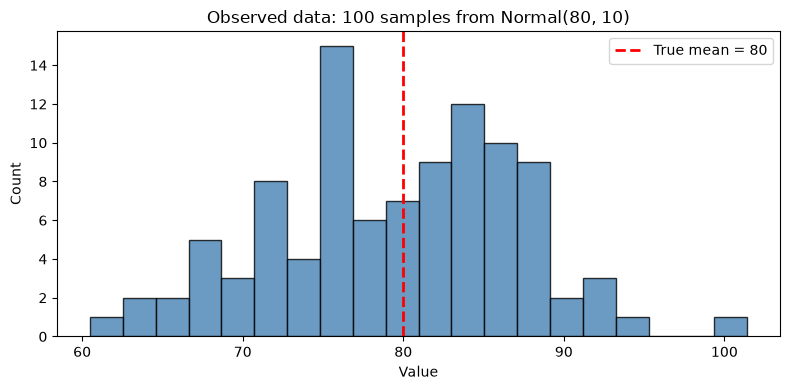

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel

SEED = 42
rng = np.random.default_rng(SEED)

N = 100
mu_true = 80
sigma_true = 10

y = rng.normal(mu_true, sigma_true, size=N)

print(f"Sample size N = {N}")
print(f"Observed sample mean = {y.mean():.2f}")
print(f"Observed sample sd = {y.std(ddof=1):.2f}")

plt.figure(figsize=(8, 4))
plt.hist(y, bins=20, color="steelblue", edgecolor="black", alpha=0.8)
plt.axvline(mu_true, color="red", linestyle="--", linewidth=2, label=f"True mean = {mu_true}")
plt.title("Observed data: 100 samples from Normal(80, 10)")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 2. Why the posterior matters

The sample mean is only one point estimate. In Bayesian inference, we explicitly estimate the entire posterior distribution for the unknown parameter. This gives us not just a single value for $\mu$, but also a credible interval such as a 95% interval.

For example, after sampling from the posterior, we can say:

- the posterior mean of $\mu$ is the center of the uncertainty distribution,
- the posterior standard deviation measures uncertainty,
- the 2.5% and 97.5% quantiles provide a 95% credible interval.

In [2]:
stan_code = """
data {
  int<lower=1> N;
  array[N] real y;
}
parameters {
  real mu;
  real<lower=0> sigma;
}
model {
  mu ~ normal(0, 50);
  sigma ~ cauchy(0, 10);
  y ~ normal(mu, sigma);
}
"""

with open("gaussian_mean_estimation.stan", "w", encoding="utf-8") as f:
    f.write(stan_code)

print("Stan model saved to gaussian_mean_estimation.stan")

model = CmdStanModel(stan_file="gaussian_mean_estimation.stan")
fit = model.sample(
    data={"N": N, "y": y.tolist()},
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED,
    show_progress=False,
)

print(fit.summary())

posterior = fit.draws_pd(vars=["mu", "sigma"])
print("\nPosterior draws for mu and sigma:")
print(posterior.head())

mu_posterior_mean = posterior["mu"].mean()
mu_lower = posterior["mu"].quantile(0.025)
mu_upper = posterior["mu"].quantile(0.975)

print(f"\nPosterior mean of mu: {mu_posterior_mean:.3f}")
print(f"Posterior 95% credible interval for mu: ({mu_lower:.3f}, {mu_upper:.3f})")


14:35:52 - cmdstanpy - INFO - compiling stan file C:\Users\SOGANG\Downloads\KOS-5101\intro-bayes\gaussian_mean_estimation.stan to exe file C:\Users\SOGANG\Downloads\KOS-5101\intro-bayes\gaussian_mean_estimation.exe


Stan model saved to gaussian_mean_estimation.stan


14:36:07 - cmdstanpy - INFO - compiled model executable: C:\Users\SOGANG\Downloads\KOS-5101\intro-bayes\gaussian_mean_estimation.exe
14:36:07 - cmdstanpy - INFO - CmdStan start processing
14:36:07 - cmdstanpy - INFO - Chain [1] start processing
14:36:07 - cmdstanpy - INFO - Chain [2] start processing
14:36:07 - cmdstanpy - INFO - Chain [3] start processing
14:36:07 - cmdstanpy - INFO - Chain [4] start processing
14:36:07 - cmdstanpy - INFO - Chain [2] done processing
14:36:07 - cmdstanpy - INFO - Chain [3] done processing
14:36:07 - cmdstanpy - INFO - Chain [4] done processing
14:36:07 - cmdstanpy - INFO - Chain [1] done processing


            Mean      MCSE    StdDev       MAD         5%        50%  \
lp__  -255.19800  0.017909  1.023470  0.736934 -257.22900 -254.88600   
mu      79.48570  0.010151  0.786478  0.795587   78.19650   79.48430   
sigma    7.84408  0.007024  0.573324  0.567940    6.97623    7.80563   

             95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_hat  
lp__  -254.22300   3689.97   4191.61     12902.0  1.000720  
mu      80.76860   6025.97   4753.52     21069.8  0.999941  
sigma    8.83416   6852.90   4789.26     23961.2  1.001790  

Posterior draws for mu and sigma:
          mu     sigma
0  77.749871  7.738301
1  81.142087  7.551962
2  80.459913  7.361112
3  78.782413  7.587771
4  79.605067  8.028811

Posterior mean of mu: 79.486
Posterior 95% credible interval for mu: (77.952, 81.023)


In [3]:
import cmdstanpy

# cmdstanpy.install_cmdstan(compiler=True, overwrite=True)

print(cmdstanpy.cmdstan_path())

C:\Users\SOGANG\.cmdstan\cmdstan-2.40.0


## 3. Interpreting the posterior output

The model above produces samples from the posterior distribution of $\mu$ and $\sigma$. The `fit.summary()` table reports the posterior mean, standard deviation, and quantiles.

In this example, we expect the posterior for $\mu$ to be centered close to the true value 80, because the sample is generated from a normal distribution with mean 80. The uncertainty becomes smaller as the sample size grows. The credible interval tells us the range of plausible values for the mean after observing the data.

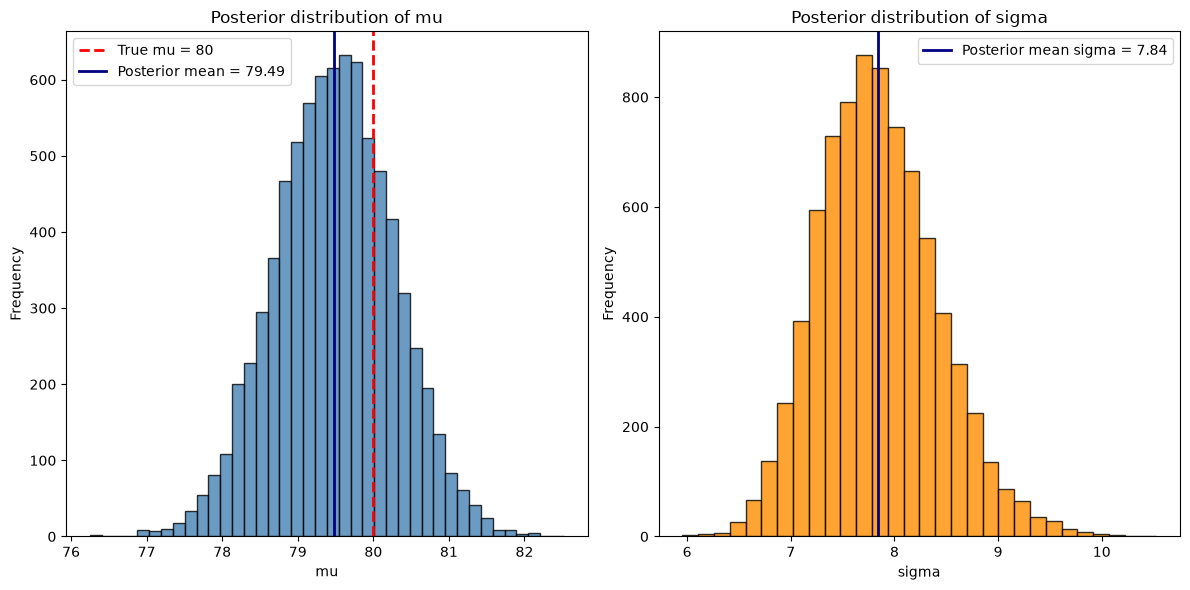

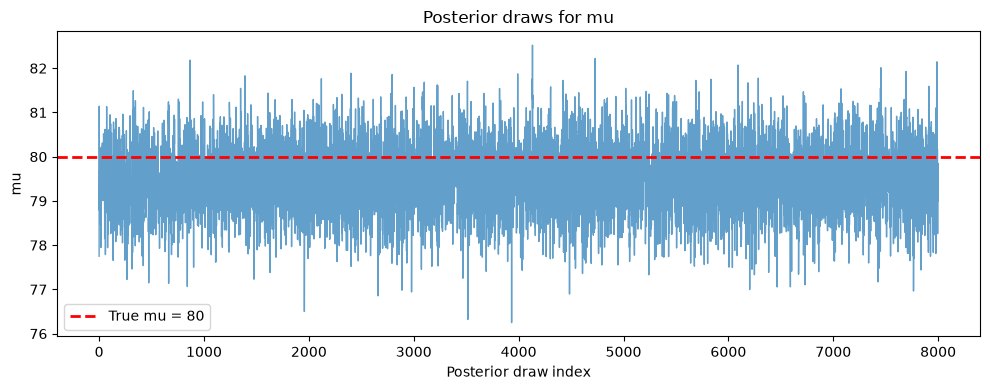

In [4]:
posterior_mu = posterior["mu"].to_numpy()
posterior_sigma = posterior["sigma"].to_numpy()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(posterior_mu, bins=40, color="steelblue", edgecolor="black", alpha=0.8)
plt.axvline(mu_true, color="red", linestyle="--", linewidth=2, label=f"True mu = {mu_true}")
plt.axvline(posterior_mu.mean(), color="navy", linestyle="-", linewidth=2, label=f"Posterior mean = {posterior_mu.mean():.2f}")
plt.title("Posterior distribution of mu")
plt.xlabel("mu")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(posterior_sigma, bins=30, color="darkorange", edgecolor="black", alpha=0.8)
plt.axvline(posterior_sigma.mean(), color="navy", linestyle="-", linewidth=2, label=f"Posterior mean sigma = {posterior_sigma.mean():.2f}")
plt.title("Posterior distribution of sigma")
plt.xlabel("sigma")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(posterior_mu)), posterior_mu, alpha=0.7, linewidth=1.0)
plt.axhline(mu_true, color="red", linestyle="--", linewidth=2, label=f"True mu = {mu_true}")
plt.title("Posterior draws for mu")
plt.xlabel("Posterior draw index")
plt.ylabel("mu")
plt.legend()
plt.tight_layout()
plt.show()


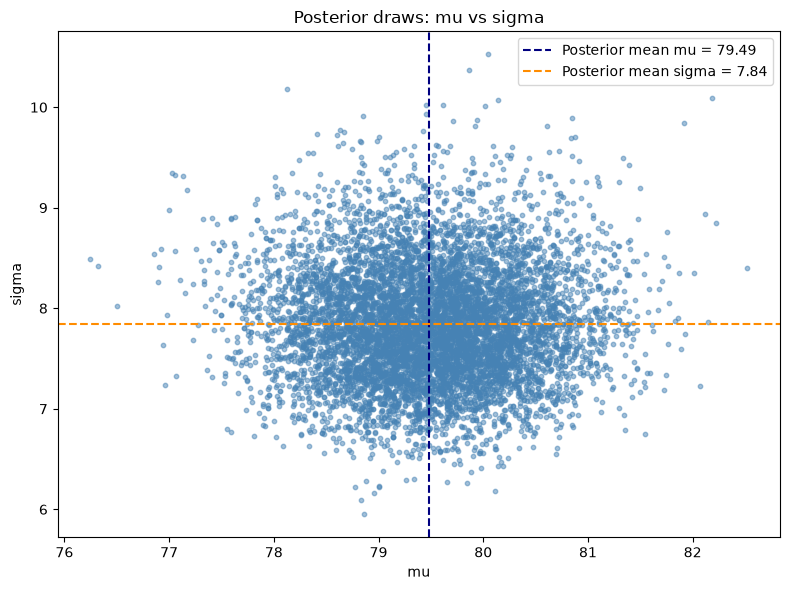

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(posterior["mu"], posterior["sigma"], alpha=0.5, s=10, color="steelblue")
plt.axvline(mu_posterior_mean, color="navy", linestyle="--", linewidth=1.5, label=f"Posterior mean mu = {mu_posterior_mean:.2f}")
plt.axhline(posterior["sigma"].mean(), color="darkorange", linestyle="--", linewidth=1.5, label=f"Posterior mean sigma = {posterior['sigma'].mean():.2f}")
plt.title("Posterior draws: mu vs sigma")
plt.xlabel("mu")
plt.ylabel("sigma")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\SOGANG\AppData\Local\Temp\ipykernel_12568\4059538624.py:42: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  vp = ax.violinplot(samples, positions=[0], vert=False, showmeans=True, showmedians=True)
C:\Users\SOGANG\AppData\Local\Temp\ipykernel_12568\4059538624.py:55: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\SOGANG\AppData\Local\Temp\ipykernel_12568\4059538624.py:42: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  vp = ax.violinplot(samples, positions=[0], vert=False, showmeans=True, showmedians=True)
C:\Users\SOGANG\AppData\Local\Temp\ipykernel_12568\4059538624.py:55: MatplotlibDeprecationWarning: vert: bool was deprecated i

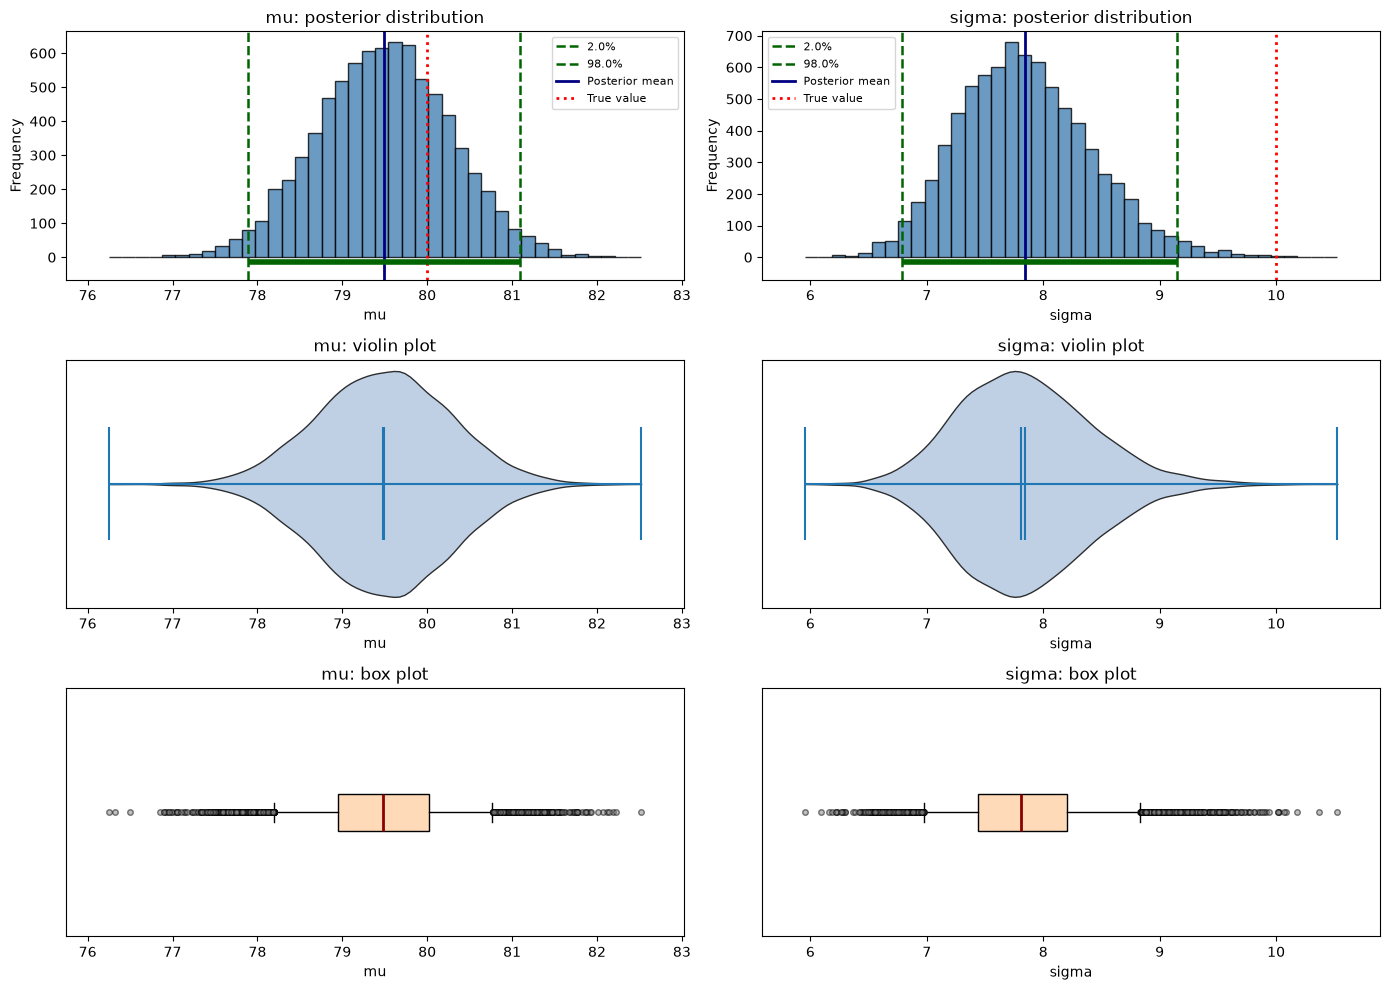

mu: mean=79.486, median=79.484, 96% CI=(77.885, 81.097)
sigma: mean=7.844, median=7.806, 96% CI=(6.788, 9.152)


In [6]:
# 96% credible intervals
ci_level = 0.96
alpha = 1 - ci_level
q_low, q_high = alpha / 2, 1 - alpha / 2

params = [
    ("mu", posterior_mu, mu_true),
    ("sigma", posterior_sigma, sigma_true),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for col, (name, samples, true_val) in enumerate(params):
    low = np.quantile(samples, q_low)
    high = np.quantile(samples, q_high)
    mean_val = np.mean(samples)
    median_val = np.median(samples)

    pad = 0.08 * (samples.max() - samples.min()) if samples.max() > samples.min() else 1.0
    x_min = samples.min() - pad
    x_max = samples.max() + pad

    # 1) Posterior distribution
    ax = axes[0, col]
    ax.hist(samples, bins=40, color="steelblue", edgecolor="black", alpha=0.8)
    ax.axvline(low, color="darkgreen", linestyle="--", linewidth=1.8, label=f"{q_low*100:.1f}%")
    ax.axvline(high, color="darkgreen", linestyle="--", linewidth=1.8, label=f"{q_high*100:.1f}%")
    ax.axvline(mean_val, color="navy", linestyle="-", linewidth=2, label="Posterior mean")
    ax.axvline(true_val, color="red", linestyle=":", linewidth=2, label="True value")
    ax.set_xlim(x_min, x_max)
    ax.set_title(f"{name}: posterior distribution")
    ax.set_xlabel(name)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8, loc="best")

    # Put the 96% CI line just below the x-axis in the same panel
    ax.hlines(-0.02 * ax.get_ylim()[1], low, high, color="darkgreen", linewidth=4, label=f"{int(ci_level*100)}% CI")
    ax.set_ylim(bottom=-0.1 * ax.get_ylim()[1], top=ax.get_ylim()[1])

    # 2) Violin plot (horizontal)
    ax = axes[1, col]
    vp = ax.violinplot(samples, positions=[0], vert=False, showmeans=True, showmedians=True)
    for body in vp["bodies"]:
        body.set_facecolor("lightsteelblue")
        body.set_edgecolor("black")
        body.set_alpha(0.8)
    ax.set_xlim(x_min, x_max)
    ax.set_yticks([])
    ax.set_title(f"{name}: violin plot")
    ax.set_xlabel(name)
    ax.set_ylabel("")

    # 3) Box plot (horizontal)
    ax = axes[2, col]
    ax.boxplot(
        samples,
        vert=False,
        patch_artist=True,
        whis=(5, 95),
        boxprops=dict(facecolor="peachpuff", color="black"),
        medianprops=dict(color="darkred", linewidth=2),
        flierprops=dict(marker="o", markersize=4, markerfacecolor="gray", alpha=0.5),
    )
    ax.set_xlim(x_min, x_max)
    ax.set_yticks([])
    ax.set_title(f"{name}: box plot")
    ax.set_xlabel(name)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# Numeric summary
for name, samples, _ in params:
    low = np.quantile(samples, q_low)
    high = np.quantile(samples, q_high)
    print(f"{name}: mean={samples.mean():.3f}, median={np.median(samples):.3f}, "
          f"{int(ci_level*100)}% CI=({low:.3f}, {high:.3f})")

C:\Users\SOGANG\AppData\Local\Temp\ipykernel_12568\2334447901.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


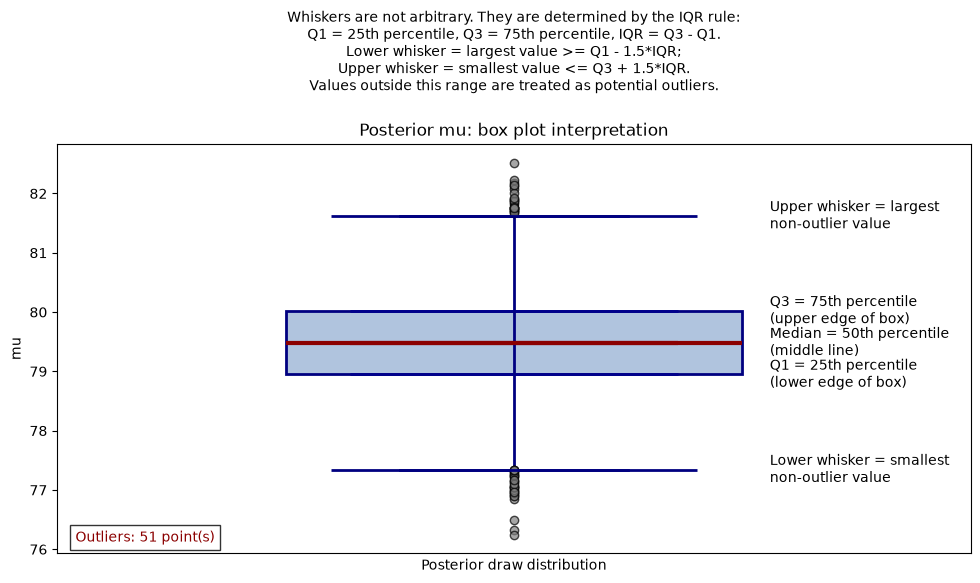

In [7]:
# Box plot of posterior mu with annotations to teach the idea of box plots
# Uses variables already created in the notebook: posterior_mu

samples = posterior_mu

# Five-number summary
q1 = np.percentile(samples, 25)
median = np.percentile(samples, 50)
q3 = np.percentile(samples, 75)
iqr = q3 - q1

# Tukey whiskers: extend to most extreme values within 1.5 * IQR
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

valid_lower = samples[samples >= lower_bound]
valid_upper = samples[samples <= upper_bound]
lower_whisker = valid_lower.min()
upper_whisker = valid_upper.max()

outliers = samples[(samples < lower_bound) | (samples > upper_bound)]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    samples,
    vert=True,
    widths=0.5,
    patch_artist=True,
    whis=1.5,  # whiskers based on 1.5 * IQR
    boxprops=dict(facecolor="lightsteelblue", edgecolor="navy", linewidth=2),
    medianprops=dict(color="darkred", linewidth=3),
    whiskerprops=dict(color="navy", linewidth=2),
    capprops=dict(color="navy", linewidth=2),
    flierprops=dict(marker="o", markersize=6, markerfacecolor="gray", alpha=0.7),
)

# Add labeled guide lines / explanations
x_center = 1.0

# Box edges and central line
ax.hlines(q1, x_center - 0.18, x_center + 0.18, color="darkblue", linewidth=2)
ax.hlines(q3, x_center - 0.18, x_center + 0.18, color="darkblue", linewidth=2)
ax.hlines(median, x_center - 0.18, x_center + 0.18, color="darkred", linewidth=3)

# Vertical span of the box
ax.vlines(x_center, q1, q3, color="navy", linewidth=2)

# Whiskers
ax.hlines(lower_whisker, x_center - 0.2, x_center + 0.2, color="navy", linewidth=2)
ax.hlines(upper_whisker, x_center - 0.2, x_center + 0.2, color="navy", linewidth=2)

# Optional labels for the main idea
ax.text(1.28, q1, "Q1 = 25th percentile\n(lower edge of box)", va="center", ha="left", fontsize=10, color="black")
ax.text(1.28, median, "Median = 50th percentile\n(middle line)", va="center", ha="left", fontsize=10, color="black")
ax.text(1.28, q3, "Q3 = 75th percentile\n(upper edge of box)", va="center", ha="left", fontsize=10, color="black")
ax.text(1.28, upper_whisker, "Upper whisker = largest\nnon-outlier value", va="center", ha="left", fontsize=10, color="black")
ax.text(1.28, lower_whisker, "Lower whisker = smallest\nnon-outlier value", va="center", ha="left", fontsize=10, color="black")

# Explain the box plot concept in plain text
ax.text(
    0.5, 1.12,
    "Whiskers are not arbitrary. They are determined by the IQR rule:\n"
    "Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 - Q1.\n"
    "Lower whisker = largest value >= Q1 - 1.5*IQR;\n"
    "Upper whisker = smallest value <= Q3 + 1.5*IQR.\n"
    "Values outside this range are treated as potential outliers.",
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10, color="black"
)

ax.set_title("Posterior mu: box plot interpretation")
ax.set_xlabel("Posterior draw distribution")
ax.set_ylabel("mu")
ax.set_xticks([])

# Add a small note about outliers if any exist
if len(outliers) > 0:
    ax.text(
        0.02, 0.02,
        f"Outliers: {len(outliers)} point(s)",
        transform=ax.transAxes,
        ha="left", va="bottom", fontsize=10, color="darkred", bbox=dict(facecolor="white", alpha=0.8)
    )

plt.tight_layout()
plt.show()

## 4. Conclusion

This notebook implemented a Bayesian normal model in Stan via `cmdstanpy` to estimate the posterior distribution of the population mean $\mu$ from simulated data.

The workflow is the same as a standard Bayesian analysis:

1. simulate data,
2. define the statistical model,
3. assign priors,
4. sample from the posterior,
5. summarize and visualize the posterior distribution.

The key practical result is that the posterior for $\mu$ concentrates around the observed data mean while also expressing uncertainty. This is exactly the value of Bayesian estimation: we obtain a full probability distribution rather than a single fixed estimate.